In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
train_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/train_dataset_v2.csv"

test_path = "/content/drive/MyDrive/TOGG_Driver_Risk_Project/data/processed/test_dataset_v2.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(243925, 87)
(66300, 87)


,acc_resultant_mean,acc_resultant_std,acc_resultant_variance,acc_resultant_min,acc_resultant_max,acc_resultant_median,acc_resultant_rms,acc_resultant_skewness,acc_resultant_kurtosis,acc_resultant_q25,...,yaw_median,yaw_rms,yaw_skewness,yaw_kurtosis,yaw_q25,yaw_q75,yaw_iqr,driver,road_type,behavior
0,0.058162,0.040807,0.001665,0.014213,0.178804,0.047605,0.070658,1.308464,1.423658,0.027403,...,-0.0335,0.033488,0.143241,-1.336769,-0.035,-0.03125,0.00375,D6,MOTORWAY,AGGRESSIVE
1,0.054311,0.033896,0.001149,0.014213,0.141287,0.047605,0.063721,0.984300,0.275005,0.027403,...,-0.0335,0.033431,0.292687,-1.044460,-0.035,-0.03125,0.00375,D6,MOTORWAY,AGGRESSIVE
2,0.055394,0.033481,0.001121,0.014213,0.141287,0.050094,0.064437,0.939426,0.288823,0.031732,...,-0.0335,0.033257,0.573495,-0.400818,-0.035,-0.03100,0.00400,D6,MOTORWAY,AGGRESSIVE
3,0.053637,0.033202,0.001102,0.014213,0.141287,0.047605,0.062790,1.093739,0.635064,0.031721,...,-0.0335,0.032998,0.832354,0.258202,-0.035,-0.03100,0.00400,D6,MOTORWAY,AGGRESSIVE
4,0.051045,0.031886,0.001017,0.014213,0.141287,0.044649,0.059903,1.305501,1.447782,0.029886,...,-0.0325,0.032622,1.001970,0.706236,-0.035,-0.03025,0.00475,D6,MOTORWAY,AGGRESSIVE


In [3]:
print(train_df.info())

print(test_df.info())

print(train_df.isnull().sum().sum())

print(test_df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243925 entries, 0 to 243924
Data columns (total 87 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   acc_resultant_mean       243925 non-null  float64
 1   acc_resultant_std        243925 non-null  float64
 2   acc_resultant_variance   243925 non-null  float64
 3   acc_resultant_min        243925 non-null  float64
 4   acc_resultant_max        243925 non-null  float64
 5   acc_resultant_median     243925 non-null  float64
 6   acc_resultant_rms        243925 non-null  float64
 7   acc_resultant_skewness   243925 non-null  float64
 8   acc_resultant_kurtosis   243925 non-null  float64
 9   acc_resultant_q25        243925 non-null  float64
 10  acc_resultant_q75        243925 non-null  float64
 11  acc_resultant_iqr        243925 non-null  float64
 12  acc_horizontal_mean      243925 non-null  float64
 13  acc_horizontal_std       243925 non-null  float64
 14  acc_

In [4]:
target_column = "behavior"

feature_columns = [

    col for col in train_df.columns

    if col not in [

        "behavior",
        "driver",
        "road_type"

    ]

]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train = train_df[target_column]
y_test = test_df[target_column]

print(X_train.shape)
print(X_test.shape)

(243925, 84)
(66300, 84)


In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)

y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['AGGRESSIVE' 'DROWSY' 'NORMAL']


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)

(243925, 84)


In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [8]:
rf_pred = rf_model.predict(
    X_test
)

rf_pred[:10]

array([0, 0, 0, 0, 2, 2, 2, 2, 2, 2])

In [9]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.4568


In [10]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

  AGGRESSIVE       0.63      0.58      0.60     15317
      DROWSY       0.69      0.31      0.43     36263
      NORMAL       0.28      0.69      0.40     14720

    accuracy                           0.46     66300
   macro avg       0.53      0.53      0.48     66300
weighted avg       0.59      0.46      0.46     66300



<Figure size 700x700 with 0 Axes>

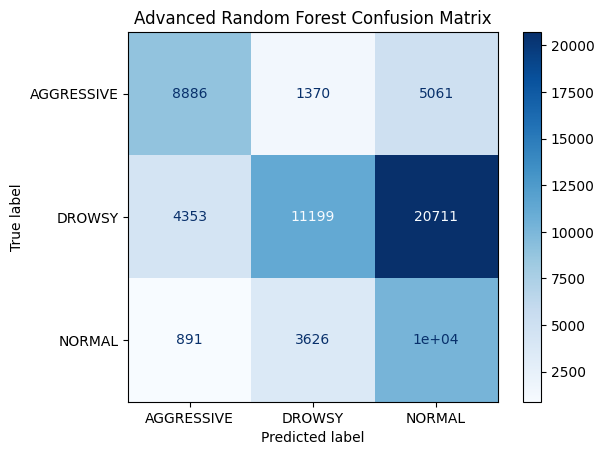

In [11]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(7,7))

disp.plot(cmap="Blues")

plt.title("Advanced Random Forest Confusion Matrix")

plt.show()

In [12]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
82,yaw_q75,0.040441
78,yaw_rms,0.040092
75,yaw_min,0.039584
76,yaw_max,0.039573
28,speed_max,0.038364
34,speed_q75,0.037694
81,yaw_q25,0.037155
77,yaw_median,0.036878
30,speed_rms,0.036723
72,yaw_mean,0.035466


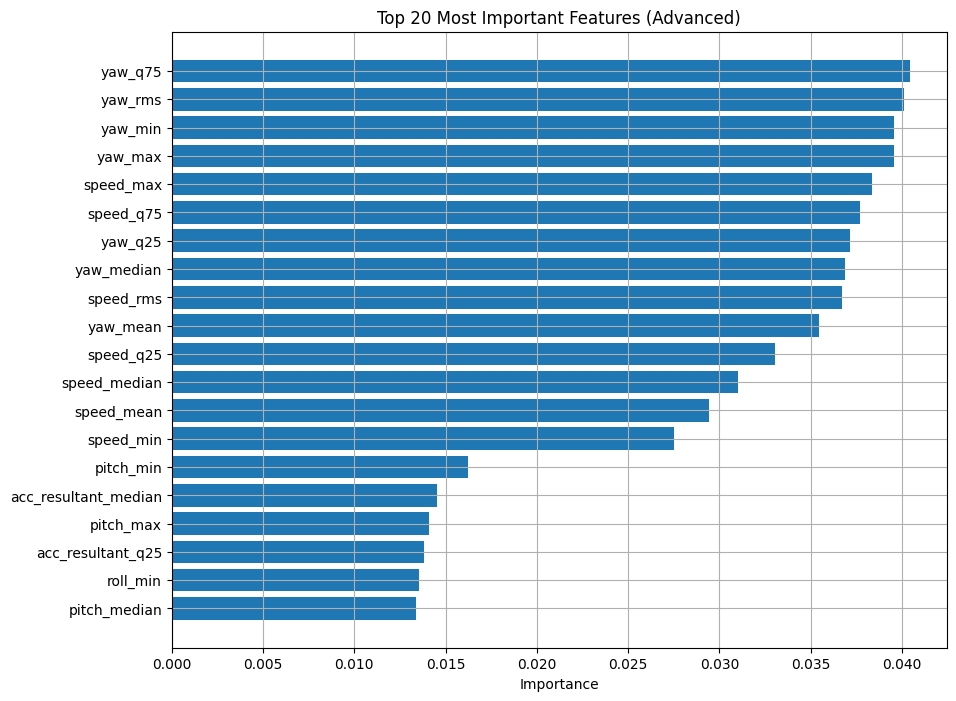

In [13]:
plt.figure(figsize=(10,8))

plt.barh(

    feature_importance["Feature"][:20][::-1],

    feature_importance["Importance"][:20][::-1]

)

plt.title("Top 20 Most Important Features (Advanced)")

plt.xlabel("Importance")

plt.grid(True)

plt.show()